# FB Cavitation Examples — Part 2

Additional Fischer-Burmeister cavitation test cases, all driven from `tests/configs/`.

| Case | Grid | Reference |
|---|---|---|
| `conv_slider_pocket_1D_hansen` | 256×4 | Hansen et al. (2022) |
| `conv_slider_pocket_1D_giacopini` | 256×4 | Giacopini et al. (2010) |
| `conv_slider_pocket_2D_wide` | 120×60 | Bertocchi et al. (2013) (1D mid-section ref.) |

Core cases (Bertocchi 1D/2D, parabolic sliders, twin sliders) are in
[15_fem_cavitation_examples.ipynb](15_fem_cavitation_examples.ipynb).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from GaPFlow.problem import Problem
from utils.plotting import plot_overview_1d, plot_overview_2d, plot_midsection_2d
from utils.topography import (
    regen_conv_slider_pocket_1d_hansen,
    regen_conv_slider_pocket_1d_giacopini,
    regen_conv_slider_pocket_2d_wide,
)

DATA_DIR = Path('../../tests/ref_data')

---
## Convergent slider with pocket — 1D, Hansen (2022) geometry

Same wedge + pocket geometry as the Bertocchi case but with different proportions
matching Hansen et al., *Tribology Letters* 70 (2022), 80, Table 3:

| Parameter | Value |
|---|---|
| Total length Lx | 10 mm |
| Inlet distance a | 2 mm |
| Pocket length b | 3 mm (x ∈ [2, 5] mm) |
| Outlet length | 5 mm |
| Gap hmax / hmin | 1.05 / 1.0 µm |
| Pocket depth | 1.0 µm |

$\rightarrow$ **[YAML File](../../tests/configs/conv_slider_pocket_1D_hansen.yaml)**

In [14]:
problem_1d_hansen = Problem.from_yaml('../../tests/configs/conv_slider_pocket_1D_hansen.yaml')
regen_conv_slider_pocket_1d_hansen(problem_1d_hansen, Nx_geo=50)
problem_1d_hansen.run()

Reading input file: ../../tests/configs/conv_slider_pocket_1D_hansen.yaml
*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/conv_slider_pocket_1D_hansen
  - write_freq               : 5
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 150
  - Lx                       : 0.01
  - dx                       : 6.666666666666667e-05
  - Ny                       : 12
  - Ly                       : 0.1
  - dy                       : 0.008333333333333333
  - dim                      : 2
  - bc_xW                    : ['D', 'N', 'N']
  - bc_xE                    : ['D', 'N', 'N']
  - bc_xW_P_val              : 

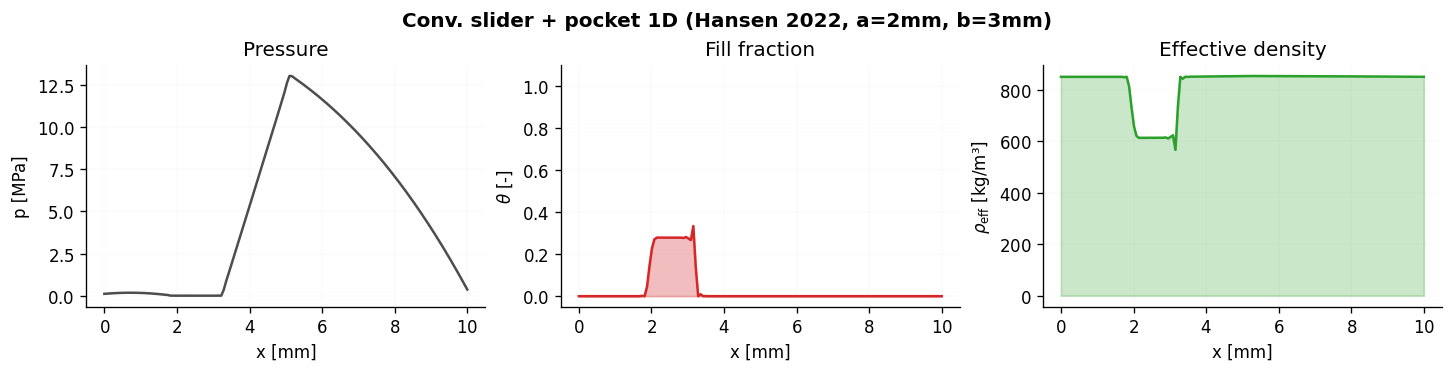

In [15]:
plot_overview_1d(
    problem_1d_hansen,
    title='Conv. slider + pocket 1D (Hansen 2022, a=2mm, b=3mm)',
    p_unit='MPa', p_divisor=1e6,
)

---
## Convergent slider with pocket — 1D, Giacopini (2010) Table 3

Converging pocketed bearing from Giacopini et al., *J. Tribology* 132 (2010), 041702, Table 3.
Validated against the semi-analytical solution of Fowell et al. [37].

| Parameter | Value |
|---|---|
| Total length Lx | 10 mm (b=2 mm + c=3 mm + d=5 mm) |
| Pocket x-extent | x ∈ [2, 5] mm |
| Convergence ratio K | 0.01 |
| hmin | 1.0 µm |
| hmax = hmin/(1−K) | ≈ 1.0101 µm |
| Pocket depth h_p = 5·hmin | 5.0 µm |
| p_in = p_out | 0.1 MPa |
| η | 0.01 Pa·s |
| U | 1.0 m/s |

$\rightarrow$ **[YAML File](../../tests/configs/conv_slider_pocket_1D_giacopini.yaml)**

In [2]:
problem_1d_giacopini = Problem.from_yaml('../../tests/configs/conv_slider_pocket_1D_giacopini.yaml')
regen_conv_slider_pocket_1d_giacopini(problem_1d_giacopini, Nx_geo=50)
problem_1d_giacopini.run()

Reading input file: ../../tests/configs/conv_slider_pocket_1D_giacopini.yaml
*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/conv_slider_pocket_1D_giacopini
  - write_freq               : 10
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 100
  - Lx                       : 0.01
  - dx                       : 0.0001
  - Ny                       : 4
  - Ly                       : 0.004
  - dy                       : 0.001
  - dim                      : 2
  - bc_xW                    : ['D', 'N', 'N']
  - bc_xE                    : ['D', 'N', 'N']
  - bc_xW_P_val              : 100000.0
  - bc_xE_P_v

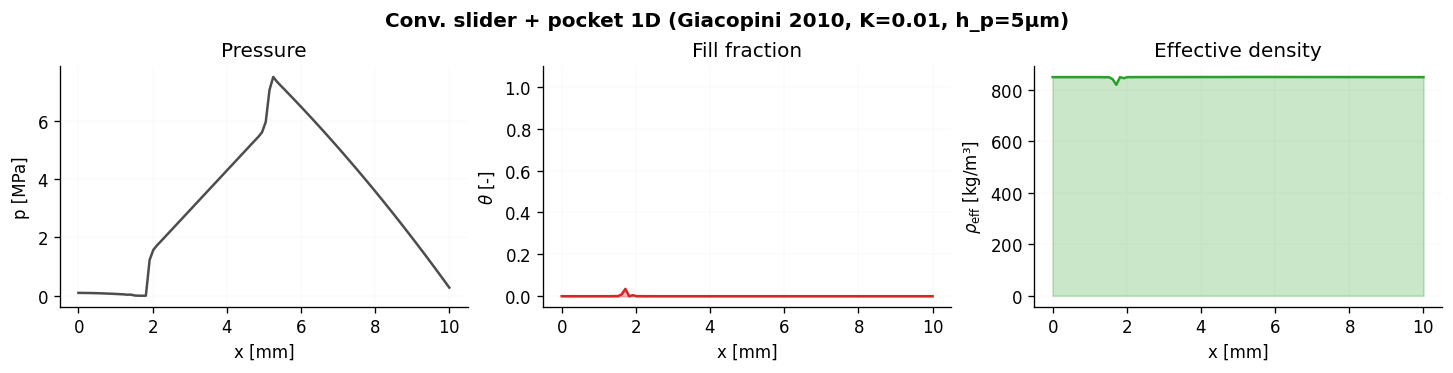

In [3]:
plot_overview_1d(
    problem_1d_giacopini,
    title='Conv. slider + pocket 1D (Giacopini 2010, K=0.01, h_p=5µm)',
    p_unit='MPa', p_divisor=1e6,
)

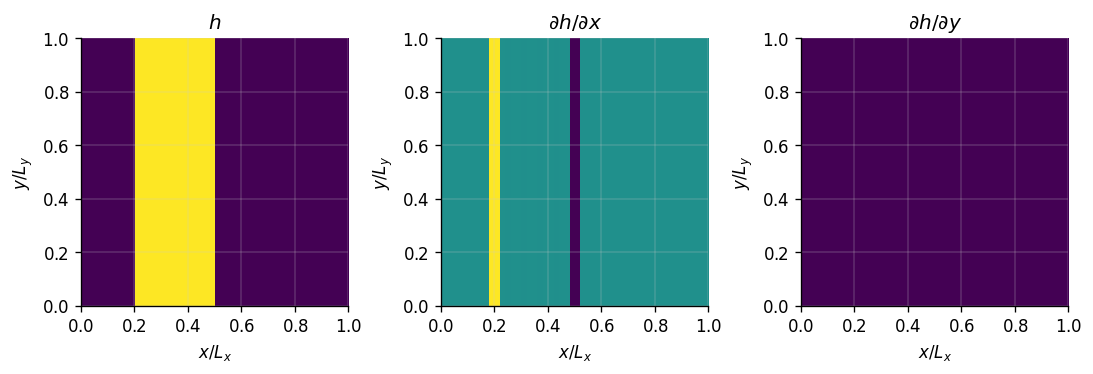

In [73]:
problem_1d_giacopini.plot_topo()

---
## Convergent slider with pocket — 2D wide domain

Same wedge and pocket geometry as the standard 2D case, but with a wider domain
(Ly=300 mm) and a correspondingly wider pocket (210 mm, centred in y).

Note: $C_2 = 6.22e09$

$\rightarrow$ **[YAML File](../../tests/configs/conv_slider_pocket_2D_wide.yaml)**

In [53]:
p_max_history = []
def track_p_max():
    p_max_history.append(problem_2d_wide.solver.quad_mgr.nodal_fields['p'].pg[0][1:-1, 1:-1].max())

problem_2d_wide = Problem.from_yaml('../../tests/configs/conv_slider_pocket_2D_wide.yaml')
regen_conv_slider_pocket_2d_wide(problem_2d_wide)
problem_2d_wide.add_callback(track_p_max)
problem_2d_wide.run()

Reading input file: ../../tests/configs/conv_slider_pocket_2D_wide.yaml
*************************************************************
*                       PROBLEM SETUP                       *
*************************************************************
- options:
  - output                   : /tmp/conv_slider_pocket_2D_wide
  - write_freq               : 10
  - use_tstamp               : True
  - save_output              : False
  - print_progress           : True
  - print_metrics            : False
  - output_plots             : False
  - residual_analysis        : False
- grid:
  - Nx                       : 240
  - Lx                       : 0.02
  - dx                       : 8.333333333333333e-05
  - Ny                       : 60
  - Ly                       : 0.3
  - dy                       : 0.005
  - dim                      : 2
  - bc_xW                    : ['D', 'N', 'N']
  - bc_xE                    : ['D', 'N', 'N']
  - bc_xW_P_val              : 100000.0
  - bc_xE

Text(0, 0.5, 'p_max [Pa]')

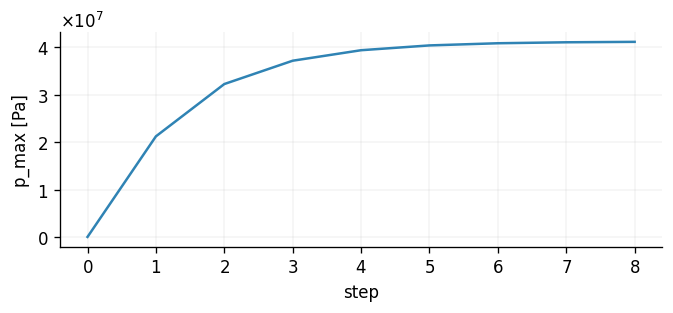

In [54]:
plt.plot(p_max_history)
plt.xlabel('step')
plt.ylabel('p_max [Pa]')

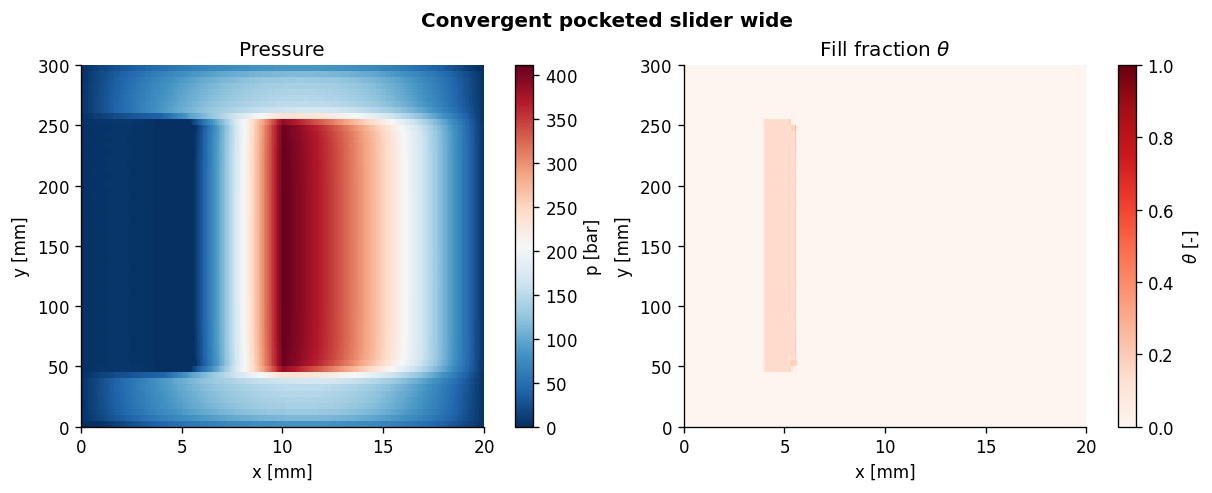

In [56]:
plot_overview_2d(problem_2d_wide, 'Convergent pocketed slider wide')

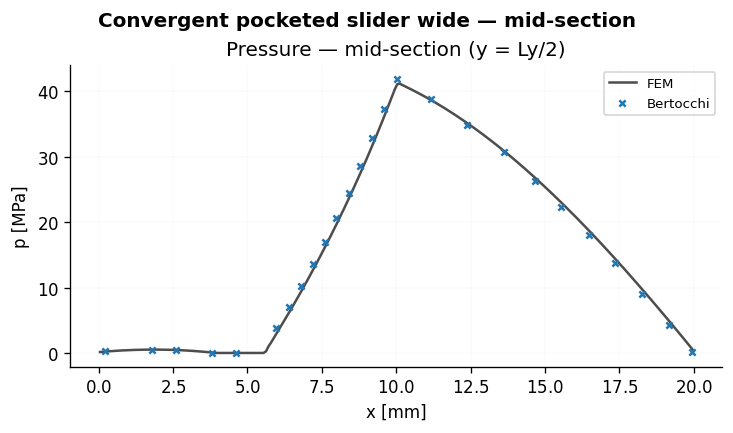

In [57]:
plot_midsection_2d(
    problem_2d_wide,
    title='Convergent pocketed slider wide — mid-section',
    ref_csv=DATA_DIR / 'ref_conv_slider_pocket_1D_FB.csv',
    ref_label='Bertocchi',
)